In [18]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

Load Dataset

In [20]:
PROCESSED_DIR="data/processed"

train_df=pd.read_csv(os.path.join(PROCESSED_DIR,"train.csv"))
test_df=pd.read_csv(os.path.join(PROCESSED_DIR,"test.csv"))
X_train=train_df.drop(columns=["class"])
X_test=test_df.drop(columns=["class"])

y_train=train_df["class"]
y_test=test_df["class"]

In [21]:
with open(os.path.join(PROCESSED_DIR, "class_labels.json")) as f:
    class_labels = {int(k): v for k, v in json.load(f).items()}

sorted_classes = sorted(class_labels.keys())

target_names = [class_labels[c] for c in sorted_classes]

feature_names = X_train.columns.tolist()
feature_names = X_train.columns.tolist()

Load the baseline Model

In [22]:
baseline_rf=joblib.load("models/random_forest_baseline.joblib")

Evaluate baseline Model

In [23]:
baseline_pred=baseline_rf.predict(X_test)
baseline_accuracy=accuracy_score(
    y_test,
    baseline_pred
)

baseline_f1=f1_score(
    y_test,
    baseline_pred,
    average="macro"
)

print("Baseline Accuracy:",baseline_accuracy)
print("Baseline F1:",baseline_f1)


Baseline Accuracy: 0.9958333333333333
Baseline F1: 0.9833797497352785


Hyperparameter tuning

In [24]:
param_grid={
    "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","log2"],
}

In [25]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

Tuning start

In [26]:
grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable adde

In [27]:
best_rf=grid_search.best_estimator_  #This is the tuned model with the best hyperparameters

print(grid_search.best_params_)

{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Evaluating the tuned model

In [28]:
best_rf = grid_search.best_estimator_
# Predict using the tuned model
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)

#Calculate the evaluation metrics
tuned_acc = accuracy_score(y_test, y_pred)

tuned_prec = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)
#print the evaluation metrics
print("===== Tuned Random Forest =====")
print(f"Accuracy:         {tuned_acc:.4f}")
print(f"Precision(macro): {tuned_prec:.4f}")
print(f"Recall(macro):    {tuned_recall:.4f}")
print(f"F1 Score(macro):  {tuned_f1:.4f}")
#print classification report
print(
    classification_report(
        y_test,
        y_pred,
        labels=sorted_classes,
        target_names=target_names,
        zero_division=0
    )
)

===== Tuned Random Forest =====
Accuracy:         0.9958
Precision(macro): 0.9691
Recall(macro):    0.9985
F1 Score(macro):  0.9834
              precision    recall  f1-score   support

hyperthyroid       0.97      1.00      0.99        33
 hypothyroid       0.94      1.00      0.97        74
      normal       1.00      1.00      1.00      1333

    accuracy                           1.00      1440
   macro avg       0.97      1.00      0.98      1440
weighted avg       1.00      1.00      1.00      1440



Confusion matrix

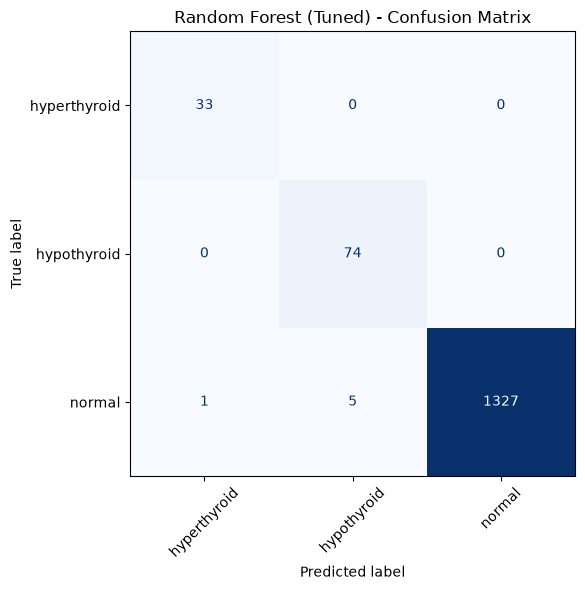

In [30]:
fig, ax = plt.subplots(figsize=(7,6))

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=sorted_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

plt.title("Random Forest (Tuned) - Confusion Matrix")
plt.tight_layout()
plt.show()

In [31]:
try:
    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="macro"
    )

    print(f"ROC-AUC (Macro OvR): {auc:.4f}")

except ValueError as e:
    print(e)

ROC-AUC (Macro OvR): 1.0000


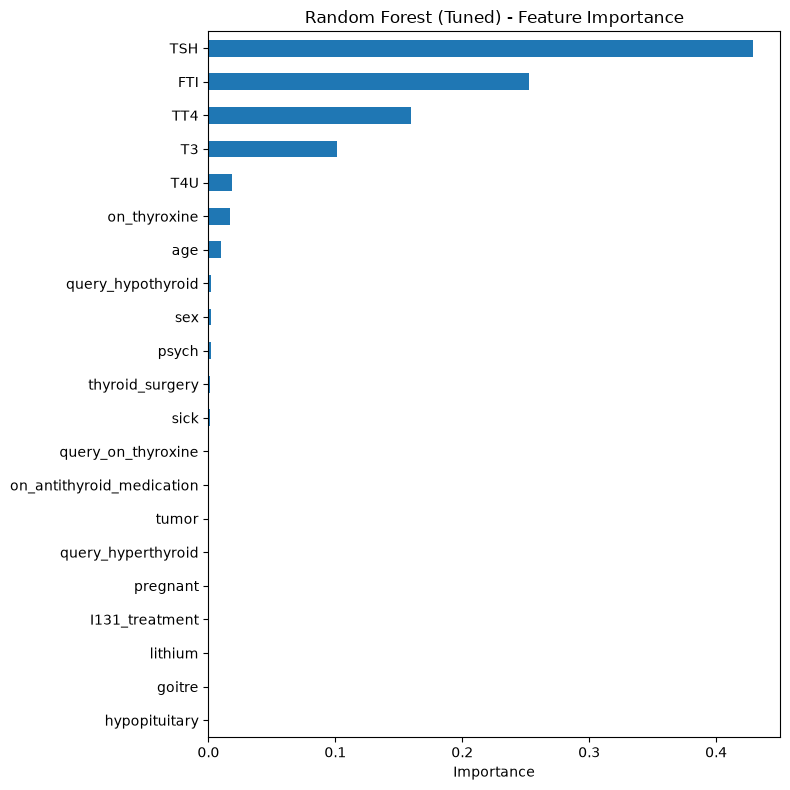

In [32]:
#feature importance
importances = best_rf.feature_importances_

feat_imp = pd.Series(
    importances,
    index=feature_names
).sort_values(ascending=False)
#plot the feature importance
plt.figure(figsize=(8,8))

feat_imp.sort_values().plot(kind="barh")

plt.title("Random Forest (Tuned) - Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [34]:
#calculate the basline metrics
baseline_pred = baseline_rf.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

baseline_precision = precision_score(
    y_test,
    baseline_pred,
    average="macro",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    average="macro",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    average="macro",
    zero_division=0
)

In [35]:
#Comparison table of basline random forest and tuned random forest
comparison = pd.DataFrame([
    {
        "Model": "Baseline Random Forest",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "F1 Score": baseline_f1
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": tuned_acc,
        "Precision": tuned_prec,
        "Recall": tuned_recall,
        "F1 Score": tuned_f1
    }
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Random Forest,0.995833,0.969099,0.9985,0.98338
1,Tuned Random Forest,0.995833,0.969099,0.9985,0.98338


In [36]:
#save the tuned model
os.makedirs("models", exist_ok=True)

joblib.dump(
    best_rf,
    "models/random_forest_tuned.joblib"
)

#save the results
os.makedirs("results", exist_ok=True)

comparison.to_csv(
    "results/random_forest_comparison.csv",
    index=False
)